### Прогнозирование риска сердечных заболеваний с использованием нейронных сетей и методов классического машинного обучения


Мы имеем набор данных, содержащие реальные клинические характеристики, используемые для анализа и прогнозирования наличия или отсутствия сердечных заболеваний.
Каждая строка представляет одного пациента, а каждый столбец - медицинский показатель измерения или диагностику.


---


### Подключение необходимых модулей


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

___

### Анализ данных

In [62]:
df = pd.read_csv('Heart_Disease_Prediction.csv')

In [63]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


| Название колонки        | Описание                                                                                                              |
| ----------------------- | --------------------------------------------------------------------------------------------------------------------- |
| Age                     | Возраст пациента (в годах)                                                                                            |
| Sex                     | Пол пациента (1 = мужчина, 0 = женщина)                                                                               |
| Chest pain type         | Тип боли в груди: 1 = Типичная стенокардия, 2 = Атипичная стенокардия, 3 = Нестенокардическая боль, 4 = Бессимптомная |
| BP                      | Давление в покое (мм рт. ст.)                                                                                         |
| Cholesterol             | Уровень холестерина в сыворотке (мг/дл)                                                                               |
| FBS over 120            | Уровень сахара натощак > 120 мг/дл (1 = истинно, 0 = ложно)                                                           |
| EKG results             | Результаты электрокардиограммы в покое: 0 = Норма, 1 = аномалия, 2 = гипертрофия левого желудочка                     |
| Max HR                  | Максимальная достигнутая частота сердечных сокращений                                                                 |
| Exercise angina         | Стенокардия, вызванная физическими упражнениями (1 = Да, 0 = Нет)                                                     |
| ST depression           | Депрессия ST, вызванная физическими упражнениями относительно отдыха                                                  |
| Slope of ST             | Наклон пикового упражнения сегмент ST                                                                                 |
| Number of vessels fluro | Количество основных сосудов (0–3), окрашенных флюороскопией                                                           |
| Thallium                | Результат стресс-теста на таллий (категориальный медицинский индикатор)                                               |
| Heart Disease           | Целевая переменная: Presence = Обнаружено сердечное заболевание, Absence = Отсутствие сердечно-сосудистых заболеваний |


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

Датасет имеет 270 строк и 14 признаков, а также полное отсутствие пропущенных значений во всех колонках


In [65]:
display(df.describe())

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


Некоторые особенности:

- 68% мужчин (1) и 32% женщин (0)

- Тип боли - Преобладают значения 3 и 4 (среднее 3.17)

- Только 15% пациентов имеют повышенный уровень сахара

- У 33% пациентов наблюдается стенокардия (примеч.) при нагрузке


**Примеч.**
Стенокардия (грудная жаба) — это давящая или щемящая боль в области сердца, которая развивается из-за недостаточного поступления кислорода к сердечной мышце.


In [66]:
# Проверка на дубликаты строк
duplicates = df.duplicated().sum()
print(f"Количество строк с дубликатами: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Удалено {duplicates} дубликатов.")

Количество строк с дубликатами: 0


In [67]:
# Проверим текущие значения целевой переменной
print("Текущие значения целевой переменной 'Heart Disease':")
print(df['Heart Disease'].value_counts())

Текущие значения целевой переменной 'Heart Disease':
Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64


Presence = Обнаружено сердечное заболевание, Absence = Отсутствие сердечно-сосудистых заболеваний 

In [68]:
# Преобразуем Presence/Absence в 1/0
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

In [69]:
print(df['Heart Disease'].value_counts())

Heart Disease
0    150
1    120
Name: count, dtype: int64


In [70]:
print(f"Процент пациентов с заболеванием: {df['Heart Disease'].mean():.2%}")

Процент пациентов с заболеванием: 44.44%


___

### Визуализация

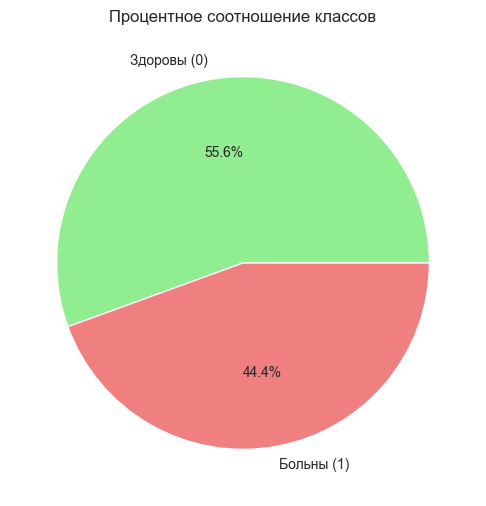

In [71]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 2)
class_counts = df['Heart Disease'].value_counts()
plt.pie(class_counts, labels=['Здоровы (0)', 'Больны (1)'], 
        autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
plt.title('Процентное соотношение классов')

plt.tight_layout()
plt.show()

<Axes: >

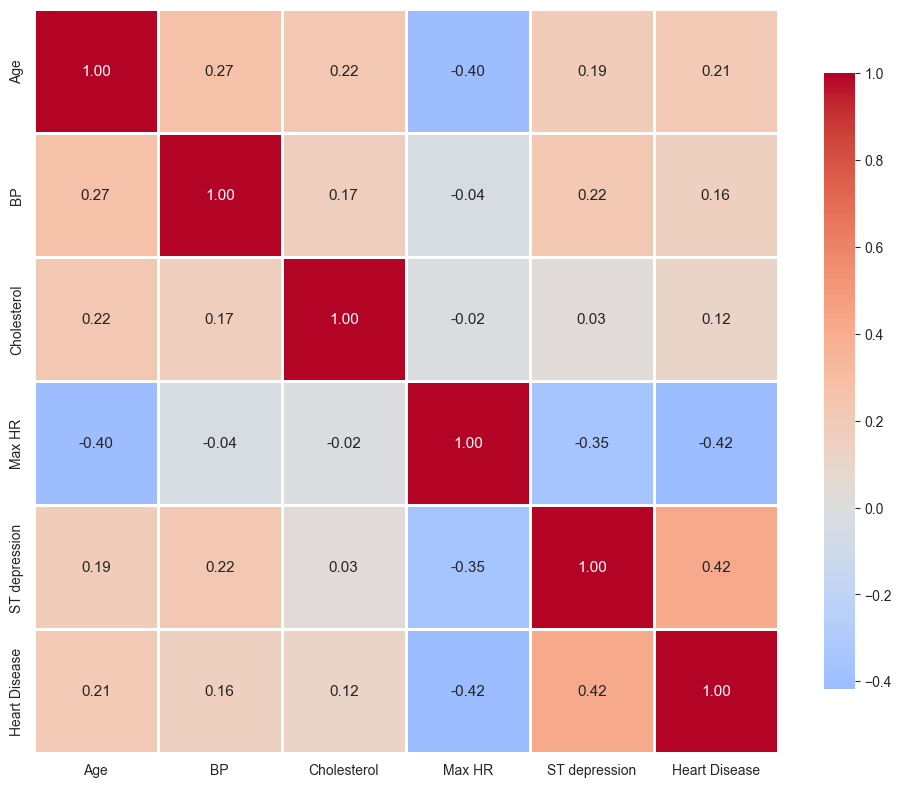

In [72]:
# Вычисляем корреляционную матризу для числовых признаков + целевая
numeric_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Heart Disease']
corr_matrix = df[numeric_cols].corr()

# Создаем аннотированную heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 11})


**Наиболее значимые признаки (сильная корреляция):**
1. Max HR (максимальный пульс): -0.419 

- Сильная отрицательная корреляция - чем выше максимальный пульс, тем ниже вероятность заболевания

- Хорошая переносимость физической нагрузки = здоровое сердце

2. ST depression (депрессия ST): +0.418

- Сильная положительная корреляция - чем больше депрессия сегмента ST, тем выше вероятность заболевания

3. Age (возраст): +0.212

 - С возрастом риск заболеваний увеличивается

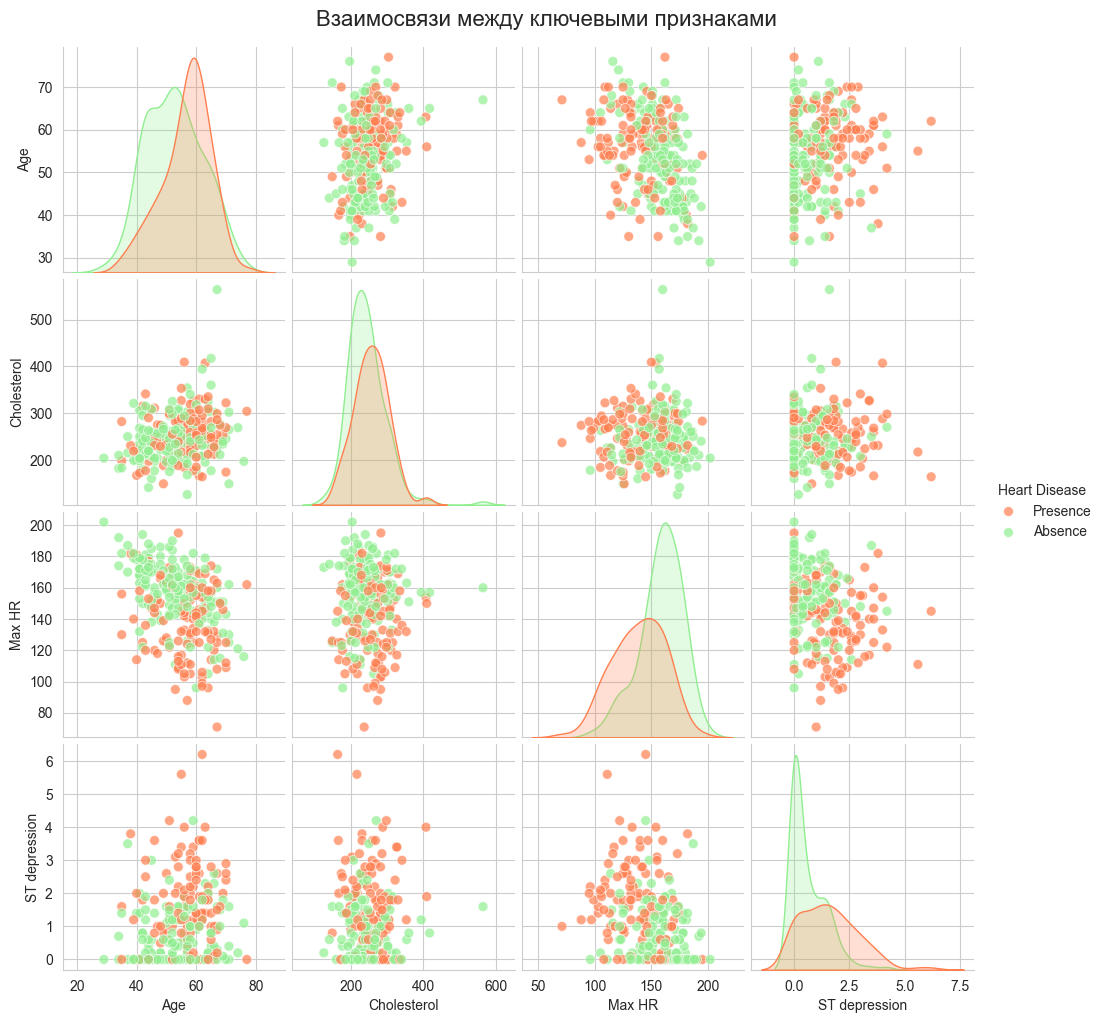

In [73]:
# Pairplot для ключевых числовых признаков
key_features = ['Age', 'Cholesterol', 'Max HR', 'ST depression', 'Heart Disease']
pairplot_data = df[key_features].copy()
pairplot_data['Heart Disease'] = pairplot_data['Heart Disease'].map({0: 'Absence', 1: 'Presence'})

g = sns.pairplot(pairplot_data, hue='Heart Disease', 
                 palette={'Absence': 'lightgreen', 'Presence': 'coral'},
                 plot_kws={'alpha': 0.7, 's': 50}, diag_kind='kde')
g.fig.suptitle('Взаимосвязи между ключевыми признаками', y=1.02, fontsize=16)
plt.show()

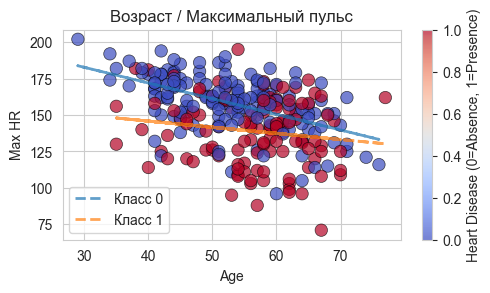

In [74]:
# Scatter plot возраст / пульс
plt.subplot(2, 2, 1)
scatter = plt.scatter(df['Age'], df['Max HR'], 
                     c=df['Heart Disease'], cmap='coolwarm', 
                     alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Heart Disease (0=Absence, 1=Presence)')
plt.xlabel('Age')
plt.ylabel('Max HR')
plt.title('Возраст / Максимальный пульс')

# Добавляем линии регрессии
import numpy as np
for target in [0, 1]:
    subset = df[df['Heart Disease'] == target]
    z = np.polyfit(subset['Age'], subset['Max HR'], 1)
    p = np.poly1d(z)
    plt.plot(subset['Age'], p(subset['Age']), 
             linestyle='--', linewidth=2, 
             label=f'Класс {target}', alpha=0.7)
plt.legend()

Синий: 0 = отсутствие болезни

Красный: 1 = наличие болезни

С возрастом максимальный пульс снижается. У здоровых людей пульс в среднем выше при том же возрасте.

___

### Предобработка данных

In [75]:
# Конвертируем значения холестерина из мг/дл в ммоль/л
df['Cholesterol_mmol'] = df['Cholesterol'] * 0.0259

print("Анализ холестерина в разных ед. измерения:")
print(f"В датасете (мг/дл): Мин={df['Cholesterol'].min()}, Макс={df['Cholesterol'].max()}, Среднее={df['Cholesterol'].mean():.1f}")
print(f"В ммоль/л: Мин={df['Cholesterol_mmol'].min():.1f}, Макс={df['Cholesterol_mmol'].max():.1f}, Среднее={df['Cholesterol_mmol'].mean():.1f}")

# Процент пациентов с повышенным холестерином (по меркам в РФ)
high_chol_count = (df['Cholesterol_mmol'] > 6).sum()
high_chol_percent = high_chol_count / len(df) * 100
print(f"Пациентов с холестерином > 6 ммоль/л: {high_chol_count} ({high_chol_percent:.1f}%)")

# Статистика по градациям
bins = [0, 5.2, 6.0, 7.8, float('inf')]  # ммоль/л
labels = ['Нормальный (<5.2)', 'Пограничный (5.2-6.0)', 'Высокий (6.0-7.8)', 'Очень высокий (>7.8)']
df['Cholesterol_category'] = pd.cut(df['Cholesterol_mmol'], bins=bins, labels=labels)

print("\nРаспределение по категориям холестерина:")
chol_dist = df['Cholesterol_category'].value_counts().sort_index()
for category, count in chol_dist.items():
    percent = count / len(df) * 100
    print(f"  {category}: {count} пациентов ({percent:.1f}%)")

# Проверяем выбросы в ммоль/л
print("Анализ критических значений:")
critical_threshold_mmol = 7.8  # очень высокий уровень
critical_cases = df[df['Cholesterol_mmol'] > critical_threshold_mmol]
print(f"Пациентов с очень высоким холестерином (>7.8 ммоль/л): {len(critical_cases)}")

if len(critical_cases) > 0:
    print("Примеры критических значений:")
    display(critical_cases[['Age', 'Cholesterol', 'Cholesterol_mmol', 'Heart Disease']].head())

Анализ холестерина в разных ед. измерения:
В датасете (мг/дл): Мин=126, Макс=564, Среднее=249.7
В ммоль/л: Мин=3.3, Макс=14.6, Среднее=6.5
Пациентов с холестерином > 6 ммоль/л: 167 (61.9%)

Распределение по категориям холестерина:
  Нормальный (<5.2): 40 пациентов (14.8%)
  Пограничный (5.2-6.0): 63 пациентов (23.3%)
  Высокий (6.0-7.8): 126 пациентов (46.7%)
  Очень высокий (>7.8): 41 пациентов (15.2%)
Анализ критических значений:
Пациентов с очень высоким холестерином (>7.8 ммоль/л): 41
Примеры критических значений:


,Age,Cholesterol,Cholesterol_mmol,Heart Disease
0,70,322,8.3398,1
1,67,564,14.6076,0
9,63,407,10.5413,1
14,57,303,7.8477,0
16,46,311,8.0549,1


61.9% пациентов имеют повышенный холестерин (>6 ммоль/л)

15.2% пациентов (41 человек) имеют критически высокий уровень (>7.8 ммоль/л)

Средний холестерин по выборке: 6.5 ммоль/л - превышает порог риска

**У пациента №1 с возрастом 67 лет и холестерином 14.6 ммоль/л (!!) при этом отсутствует сердечное заболевание. Это может указывать на ошибку в данных либо уникальный клинический случай.**

In [76]:
df['Cholesterol'] = df['Cholesterol'].clip(upper=300)

In [77]:
df = df.drop(['Cholesterol_mmol', 'Cholesterol_category'], axis=1)

In [78]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,300,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,300,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


___

### Разделение данных

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [81]:
# Разделяем признаки и целевую переменную
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # важно для несбалансированных данных
)

In [83]:
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Процент заболеваний в train: {y_train.mean():.2%}")
print(f"Процент заболеваний в test: {y_test.mean():.2%}")

Размер обучающей выборки: (216, 13)
Размер тестовой выборки: (54, 13)
Процент заболеваний в train: 44.44%
Процент заболеваний в test: 44.44%


### Масштабирование числовых признаков

In [88]:
# Определяем числовые признаки
numeric_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
# Для категориальных признаков (оставляем как есть)
categorical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                   'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

In [89]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [90]:
# Инициализируем и обучаем scaler на train данных
scaler = StandardScaler()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Применяем тот же scaler к test данным
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

___

### Нейронная сеть

In [98]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

In [93]:
# Создание модели
model_nn = keras.Sequential([
    # Входной слой
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Скрытые слои
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    
    # Выходной слой
    layers.Dense(1, activation='sigmoid')
])

In [94]:
# Компиляция модели
model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 192 (768.00 B)

In [96]:
# Callbacks для улучшения обучения
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001
    )
]

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6163 - auc: 0.6645 - loss: 0.6556 - precision: 0.5395 - recall: 0.5694 - val_accuracy: 0.6136 - val_auc: 0.7333 - val_loss: 0.6447 - val_precision: 0.5854 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6977 - auc: 0.7344 - loss: 0.5954 - precision: 0.6316 - recall: 0.6667 - val_accuracy: 0.5909 - val_auc: 0.7927 - val_loss: 0.6240 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6686 - auc: 0.7472 - loss: 0.5841 - precision: 0.6154 - recall: 0.5556 - val_accuracy: 0.6136 - val_auc: 0.8208 - val_loss: 0.6116 - val_precision: 0.5854 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7733 - auc: 0.8383 - loss: 0.4941 - precision: 0.7705 - recall: 0.6528 - val_accuracy: 0.6364 - val_auc: 0.8271 - val_loss: 0.5954 - val_pr

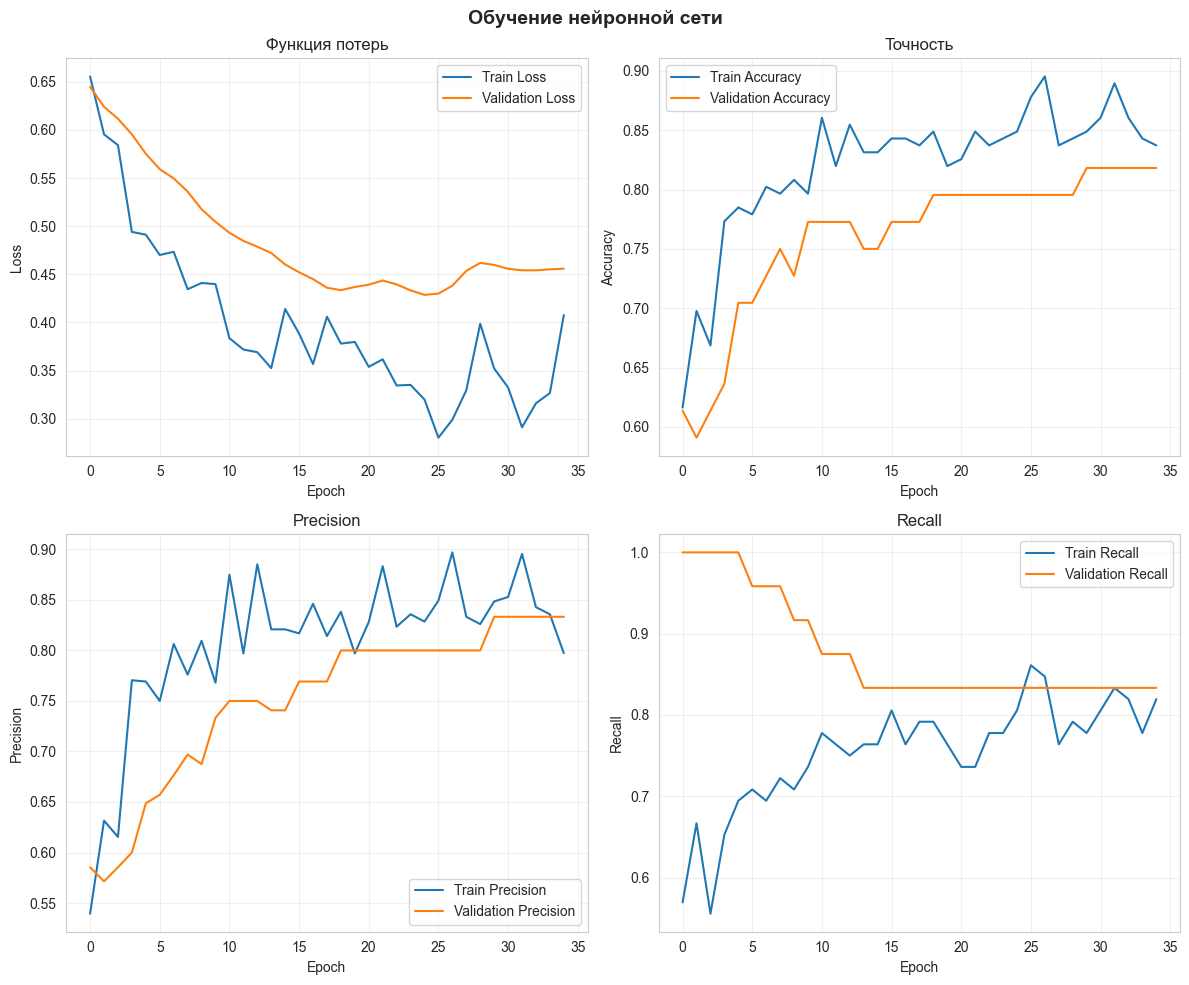

Количество эпох: 35


In [97]:
# Обучение модели
history = model_nn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)
# Визуализация процесса обучения
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Функция потерь')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Точность')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
axes[1, 0].set_title('Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
axes[1, 1].set_title('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Обучение нейронной сети', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Количество эпох: {len(history.history['loss'])}")

In [99]:
# Предсказания нейронной сети
y_pred_nn_prob = model_nn.predict(X_test_scaled).flatten()
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [102]:
print("Нейронная сеть")
print("=" * 70)
print(classification_report(y_test, y_pred_nn, 
                           target_names=['Absence (0)', 'Presence (1)'],
                           digits=4))

Нейронная сеть
              precision    recall  f1-score   support

 Absence (0)     0.9167    0.7333    0.8148        30
Presence (1)     0.7333    0.9167    0.8148        24

    accuracy                         0.8148        54
   macro avg     0.8250    0.8250    0.8148        54
weighted avg     0.8352    0.8148    0.8148        54



 **ОБЩАЯ ЭФФЕКТИВНОСТЬ:**

1. Accuracy 81.5% - хороший результат для медицинской диагностики

2. F1-score одинаков для обоих классов (0.8148) - модель одинаково хорошо распознает и здоровых, и больных

**Для класса "Отсутствие болезни" (0):**

1. Precision (91.7%) - из всех предсказанных "здоровых" 91.7% действительно здоровы

2. Recall (73.3%) - модель находит 73.3% реально здоровых пациентов

 **Модель осторожна в диагностике здоровья - реже ошибается, но может пропускать**

**Для класса "Наличие болезни" (1):**

1. Precision (73.3%) - Из всех предсказанных "больных" 73.3% действительно больны

2. Recall (91.7%): Модель находит 91.7% реально больных пациентов

**Модель чувствительна к болезни - находит почти всех больных, но с риском ложных срабатываний**

In [107]:
cm = confusion_matrix(y_test, y_pred_nn)
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(cm, 
                     index=['Actual: Absence', 'Actual: Presence'], 
                     columns=['Predicted: Absence', 'Predicted: Presence'])

print("\nМатрица ошибок:")
print(cm_df)
print(f"\nЭлементы матрицы:")
print(f"  True Negative (TN): {tn} - правильно предсказанные здоровые")
print(f"  False Positive (FP): {fp} - ложные срабатывания")
print(f"  False Negative (FN): {fn} - пропущенные болезни")
print(f"  True Positive (TP): {tp} - правильно предсказанные больные")


Матрица ошибок:
                  Predicted: Absence  Predicted: Presence
Actual: Absence                   22                    8
Actual: Presence                   2                   22

Элементы матрицы:
  True Negative (TN): 22 - правильно предсказанные здоровые
  False Positive (FP): 8 - ложные срабатывания
  False Negative (FN): 2 - пропущенные болезни
  True Positive (TP): 22 - правильно предсказанные больные


**False Positive (8 случаев)** - здоровые пациенты ошибочно диагностированы как больные
**False Negative (2 случая):** Больные пациенты ошибочно диагностированы как здоровые

___

### Random Forest (без масштабирования)

In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [109]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

In [110]:
rf_model.fit(X_train, y_train)
print(f"Количество деревьев: {rf_model.n_estimators}")
print(f"Глубина деревьев: {rf_model.max_depth}")

Количество деревьев: 150
Глубина деревьев: 12


In [112]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [113]:
print("CLASSIFICATION REPORT (Random Forest)")
print("=" * 70)
print(classification_report(y_test, y_pred_rf, 
                           target_names=['Absence (0)', 'Presence (1)'],
                           digits=4))

CLASSIFICATION REPORT (Random Forest)
              precision    recall  f1-score   support

 Absence (0)     0.8571    0.8000    0.8276        30
Presence (1)     0.7692    0.8333    0.8000        24

    accuracy                         0.8148        54
   macro avg     0.8132    0.8167    0.8138        54
weighted avg     0.8181    0.8148    0.8153        54



**ОБЩАЯ ЭФФЕКТИВНОСТЬ:**
1. Accuracy - 81.5% - идентично нейронной сети

2. F1-score немного лучше для здоровых (0.8276/0.8000)

**Для класса "Отсутствие болезни" (0):**

1. Precision (85.7%) - на 6.0% ниже, чем у нейросети (91.7%)

2. Recall (80.0%) - На 6.7% выше, чем у нейросети (73.3%)

**Лучше находит здоровых, но чаще ошибается в их диагностике**

**Для класса "Наличие болезни" (1):**

1. Precision (76.9%) - на 3.6% выше, чем у нейросети (73.3%)

2. Recall (83.3%) - на 8.4% ниже, чем у нейросети (91.7%)

**Точнее диагностирует болезнь, но пропускает больше больных**

In [114]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
total = tn_rf + fp_rf + fn_rf + tp_rf

cm_rf_df = pd.DataFrame(cm_rf, 
                       index=['Actual: Absence', 'Actual: Presence'], 
                       columns=['Predicted: Absence', 'Predicted: Presence'])

print("\nConfusion Matrix:")
print(cm_rf_df)
print(f"\nЭлементы матрицы:")
print(f"  True Negative (TN): {tn_rf} - правильно предсказанные здоровые")
print(f"  False Positive (FP): {fp_rf} - ложные срабатывания")
print(f"  False Negative (FN): {fn_rf} - пропущенные болезни")
print(f"  True Positive (TP): {tp_rf} - правильно предсказанные больные")


Confusion Matrix:
                  Predicted: Absence  Predicted: Presence
Actual: Absence                   24                    6
Actual: Presence                   4                   20

Элементы матрицы:
  True Negative (TN): 24 - правильно предсказанные здоровые
  False Positive (FP): 6 - ложные срабатывания
  False Negative (FN): 4 - пропущенные болезни
  True Positive (TP): 20 - правильно предсказанные больные


**False Positive (6/8)** - Random Forest совершает на 2 меньше ложных срабатываний

**False Negative (4/2)** - пропускает на 2 больше больных

**True Positive (20/22):** - находит на 2 меньше реально больных

**True Negative (24/22):** - правильно определяет на 2 больше здоровых

### Вывод по сравнению метрик

Обе модели имеют одинаковую общую точность (81.5%)

Разный баланс ошибок:

Нейросеть предпочитает перестраховаться (меньше FN, больше FP)

Random Forestt более осторожен с диагнозом (меньше FP, больше FN)

**Для скрининга лучше нейросеть (выше чувствительность), для подтверждающей диагностики лучше Random Forest (выше precision)**

___

### Вывод

Проведено исследование по прогнозированию сердечно-сосудистых заболеваний с использованием двух различных подходов машинного обучения. Обе модели достигли высоких результатов (81.5% точности), что подтверждает возможность эффективного применения ML в медицинской диагностике.

**КЛЮЧЕВЫЕ ЭТАПЫ И РЕЗУЛЬТАТЫ:**
1. АНАЛИЗ ДАННЫХ:

Обнаружена критически высокая распространенность гиперхолестеринемии (61.9% пациентов > 6 ммоль/л)

Выявлены сильные корреляции - Max HR (-0.42) и ST depression (+0.42) наиболее связаны с заболеванием

Датасет сбалансирован (≈50/50), что обеспечило надежное обучение моделей

2. ПРЕДОБРАБОТКА:

Обработаны экстремальные выбросы холестерина (обрезка на 300 мг/дл)

Сохранена медицинская значимость данных

Применено масштабирование для нейронной сети

3. МОДЕЛИ И ИХ ХАРАКТЕРИСТИКИ:

**Нейронная сеть:**

3 скрытых слоя (64-32-16 нейронов) с Dropout и BatchNorm

Сильные стороны - высокая чувствительность (Recall=91.7% для больных)

Слабые стороны - больше ложных срабатываний (FP=8)

**Random Forest:**

150 деревьев, глубина 12, сбалансированные классы

Сильные стороны - лучшая специфичность (меньше FP=6)

Слабые стороны - ниже чувствительность (пропускает больше больных)

___

Таким образом, исследование успешно продемонстрировало возможность создания эффективных моделей для прогнозирования сердечно-сосудистых заболеваний. 

Обе модели показали высокую точность, но с разными диагностическими профилями. Для реального клинического применения рекомендуется гибридный подход - использование Random Forest для первичной сортировки и нейронной сети для сложных случаев. Работа имеет практическую ценность и может служить основой для создания системы поддержки врачебных решений в кардиологии.